In [1]:

# CELL 1: Imports

 
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
 
 

In [2]:

# CELL 2: Load single match data (for development/testing)

 
match_id = "3902240"
 
# Load events
with open(f"data_raw/data/events/{match_id}.json") as f:
    events = json.load(f)
 
# Load 360 freeze frames
with open(f"data_raw/data/three-sixty/{match_id}.json") as f:
    three_sixty = json.load(f)
 
print(f"Events loaded: {len(events)}")
print(f"360 frames loaded: {len(three_sixty)}")
 

Events loaded: 4576
360 frames loaded: 3811


In [3]:

# CELL 3: Extract passes into a flat table

 
rows = []
for event in events:
    if event['type']['name'] == 'Pass':
        rows.append({
            'event_id'  : event['id'],
            'player'    : event['player']['name'],
            'team'      : event['team']['name'],
            'period'    : event['period'],
            'x'         : event['location'][0],
            'y'         : event['location'][1],
            'end_x'     : event['pass']['end_location'][0],
            'end_y'     : event['pass']['end_location'][1],
            'pass_type' : event['pass'].get('type', {}).get('name', 'Regular'),
            'outcome'   : event['pass'].get('outcome', {}).get('name', 'Complete'),
        })
 
df = pd.DataFrame(rows)
print(f"Total passes: {len(df)}")
 
 

Total passes: 1221


In [4]:

# CELL 4: Filter to open play forward passes

 
# Remove set pieces, throw-ins, kick offs and interceptions
# Consistent with Deb et al. (2023) and Opta who treat set play
# and open play as analytically distinct contexts
excluded_types = ['Free Kick', 'Corner', 'Goal Kick', 'Kick Off', 'Throw-in', 'Interception']
df = df[~df['pass_type'].isin(excluded_types)]
 
# Remove injury clearances — not tactical passes
df = df[df['outcome'] != 'Injury Clearance']
 
# Remove backward passes — only interested in forward intent
df = df[df['end_x'] > df['x']]
 
print(f"Open play forward passes: {len(df)}")
print(f"\nOutcome breakdown:")
print(df['outcome'].value_counts())
 

Open play forward passes: 687

Outcome breakdown:
outcome
Complete        424
Incomplete      217
Out              37
Unknown           5
Pass Offside      4
Name: count, dtype: int64


In [5]:

# CELL 5: Build 360 freeze frame lookup

 
# Build a dictionary: event_id -> freeze_frame
# This allows instant lookup of player positions for any pass
freeze_frame_lookup = {}
for frame_data in three_sixty:
    event_id = frame_data['event_uuid']
    freeze_frame_lookup[event_id] = frame_data['freeze_frame']
 
# Filter passes to only those with 360 data available
passes_with_360 = df[df['event_id'].isin(freeze_frame_lookup)].copy()
 
print(f"Total passes: {len(df)}")
print(f"Passes with 360 data: {len(passes_with_360)} ({len(passes_with_360)/len(df):.1%})")
 
 

Total passes: 687
Passes with 360 data: 591 (86.0%)


In [6]:

# CELL 6: Defensive line detection functions

 
def detect_defensive_lines(opponents, depth_tolerance=3):
    """
    Groups opponents into defensive lines based on similar x depth.
 
    Parameters:
        opponents: list of opponent players from freeze frame
        depth_tolerance: max x difference to be in the same line (default 3 units)
                        empirically grounded — median inter-defender gap = 2.54 units,
                        derived from 200 freeze frames
 
    Returns:
        list of lines, each line is a list of players with >= 2 members
    """
    if len(opponents) < 2:
        return []
 
    # Sort opponents by x position (depth)
    sorted_opponents = sorted(opponents, key=lambda p: p['location'][0])
 
    lines = []
    current_group = [sorted_opponents[0]]
 
    for player in sorted_opponents[1:]:
        prev_x = current_group[-1]['location'][0]
        curr_x = player['location'][0]
 
        if curr_x - prev_x <= depth_tolerance:
            current_group.append(player)
        else:
            if len(current_group) >= 2:
                lines.append(current_group)
            current_group = [player]
 
    # Check the last group
    if len(current_group) >= 2:
        lines.append(current_group)
 
    return lines
 
 
def is_line_breaking(pass_x, pass_end_x, pass_end_y, lines):
    """
    Checks if a pass breaks any detected defensive line.
 
    A pass is line-breaking if:
    1. The line is ahead of the passer
    2. The pass end x is beyond the line
    3. The pass end y falls within the y range of the line
 
    Returns:
        True if line-breaking, False otherwise
    """
    for line in lines:
        x_vals = [p['location'][0] for p in line]
        y_vals = [p['location'][1] for p in line]
 
        line_x     = min(x_vals)
        line_y_min = min(y_vals)
        line_y_max = max(y_vals)
 
        # Line must be ahead of the passer
        if line_x <= pass_x:
            continue
 
        # Pass must end beyond the line
        if pass_end_x <= line_x:
            continue
 
        # Pass must end within the y range of the line
        if line_y_min <= pass_end_y <= line_y_max:
            return True
 
    return False
 
 
def get_lbpa_features(pass_x, pass_end_x, pass_end_y, lines):
    """
    Returns detailed LBPA features for a pass.
 
    Parameters:
        pass_x: x position of passer
        pass_end_x: x destination of pass
        pass_end_y: y destination of pass
        lines: detected defensive lines
 
    Returns:
        dictionary with is_lbpa, n_lines_broken, n_defenders_bypassed, progression_depth
    """
    n_lines_broken = 0
    n_defenders_bypassed = 0
 
    for line in lines:
        x_vals = [p['location'][0] for p in line]
        y_vals = [p['location'][1] for p in line]
 
        line_x     = min(x_vals)
        line_y_min = min(y_vals)
        line_y_max = max(y_vals)
 
        if line_x <= pass_x:
            continue
        if pass_end_x <= line_x:
            continue
        if line_y_min <= pass_end_y <= line_y_max:
            n_lines_broken += 1
            n_defenders_bypassed += sum(1 for p in line if p['location'][0] < pass_end_x)
 
    return {
        'is_lbpa'              : n_lines_broken > 0,
        'n_lines_broken'       : n_lines_broken,
        'n_defenders_bypassed' : n_defenders_bypassed,
        'progression_depth'    : pass_end_x
    }
 
 
print("All functions defined successfully")

All functions defined successfully


In [7]:

# CELL 7: Apply detection to single match (sense check)

 
results = []
 
for _, row in passes_with_360.iterrows():
    frame = freeze_frame_lookup[row['event_id']]
 
    # Get outfield opponents only (exclude keeper)
    opponents = [p for p in frame
                 if p['teammate'] == False
                 and p['keeper'] == False]
 
    # Detect defensive lines
    lines = detect_defensive_lines(opponents)
 
    # Get LBPA features
    features = get_lbpa_features(row['x'], row['end_x'], row['end_y'], lines)
 
    results.append({
        'event_id'             : row['event_id'],
        'player'               : row['player'],
        'team'                 : row['team'],
        'x'                    : row['x'],
        'y'                    : row['y'],
        'end_x'                : row['end_x'],
        'end_y'                : row['end_y'],
        'outcome'              : row['outcome'],
        'n_lines'              : len(lines),
        'is_lbpa'              : features['is_lbpa'],
        'n_lines_broken'       : features['n_lines_broken'],
        'n_defenders_bypassed' : features['n_defenders_bypassed'],
        'progression_depth'    : features['progression_depth']
    })
 
results_df = pd.DataFrame(results)
 
print(f"Total passes analysed: {len(results_df)}")
print(f"LBPAs detected: {results_df['is_lbpa'].sum()}")
print(f"LBPA rate: {results_df['is_lbpa'].mean():.1%}")
print(f"\nLBPA rate by team:")
print(results_df.groupby('team')['is_lbpa'].mean().round(3))
print(f"\nOutcome breakdown for LBPAs:")
print(results_df[results_df['is_lbpa']]['outcome'].value_counts())
 

Total passes analysed: 591
LBPAs detected: 157
LBPA rate: 26.6%

LBPA rate by team:
team
Netherlands Women's    0.278
Spain Women's          0.258
Name: is_lbpa, dtype: float64

Outcome breakdown for LBPAs:
outcome
Incomplete      77
Complete        73
Out              5
Unknown          1
Pass Offside     1
Name: count, dtype: int64


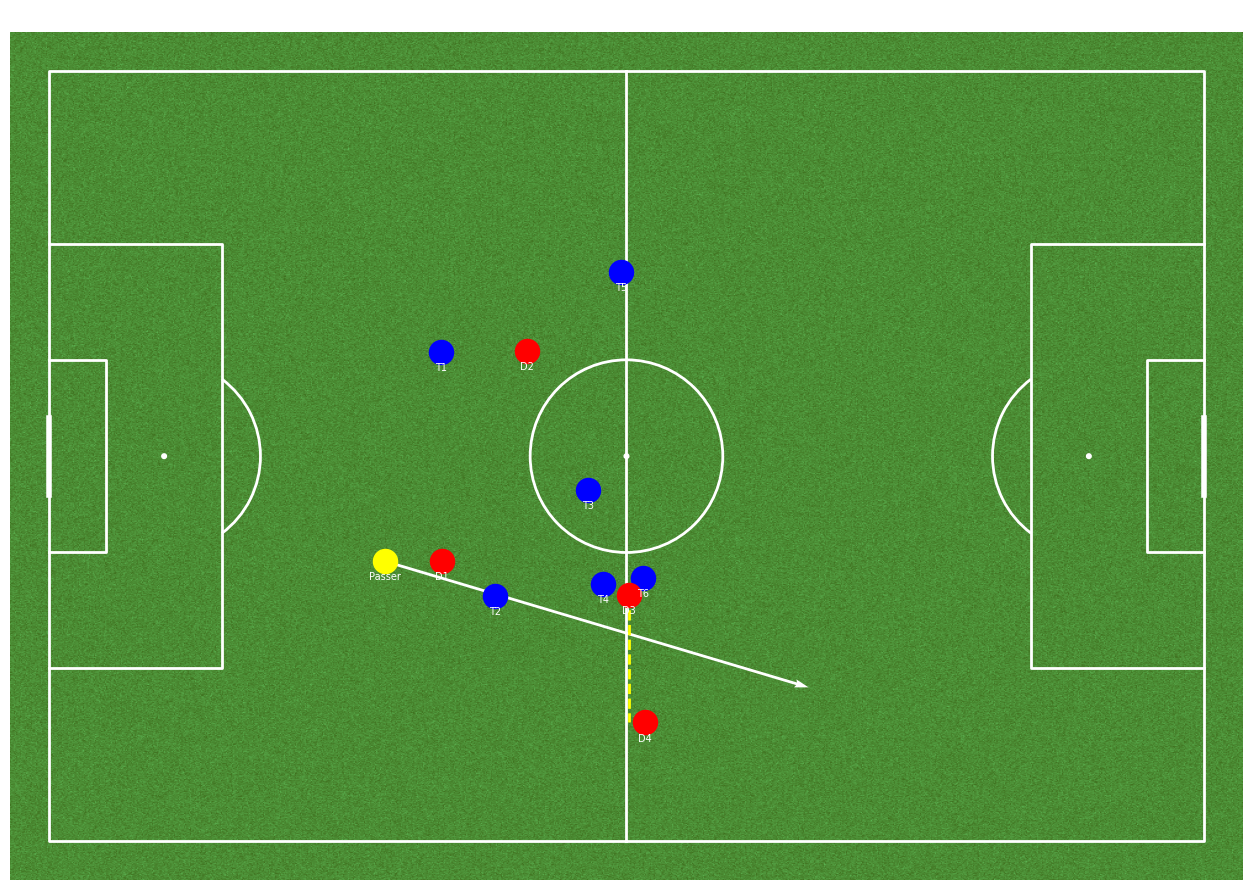

In [8]:

# CELL 8: Visualise a single LBPA on pitch
 
sample_lbpa = results_df[results_df['is_lbpa'] == True].iloc[0]
frame = freeze_frame_lookup[sample_lbpa['event_id']]
 
teammates = [p for p in frame if p['teammate'] == True and p['actor'] == False]
passer    = [p for p in frame if p['actor'] == True]
opponents = [p for p in frame if p['teammate'] == False and p['keeper'] == False]
keeper    = [p for p in frame if p['teammate'] == False and p['keeper'] == True]
 
lines = detect_defensive_lines(opponents)
 
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(14, 9))
 
for i, p in enumerate(teammates):
    ax.scatter(*p['location'], color='blue', s=300, zorder=3)
    ax.text(p['location'][0], p['location'][1] + 2, f'T{i+1}', color='white', fontsize=7, ha='center', zorder=4)
 
for p in passer:
    ax.scatter(*p['location'], color='yellow', s=300, zorder=3)
    ax.text(p['location'][0], p['location'][1] + 2, 'Passer', color='white', fontsize=7, ha='center', zorder=4)
 
for i, p in enumerate(opponents):
    ax.scatter(*p['location'], color='red', s=300, zorder=3)
    ax.text(p['location'][0], p['location'][1] + 2, f'D{i+1}', color='white', fontsize=7, ha='center', zorder=4)
 
for p in keeper:
    ax.scatter(*p['location'], color='orange', s=300, zorder=3)
    ax.text(p['location'][0], p['location'][1] + 2, 'GK', color='white', fontsize=7, ha='center', zorder=4)
 
# Draw pass arrow
pitch.arrows(sample_lbpa['x'], sample_lbpa['y'],
             sample_lbpa['end_x'], sample_lbpa['end_y'],
             ax=ax, color='white', width=2)
 
# Draw detected defensive lines as yellow dashed lines
for line in lines:
    x_vals = [p['location'][0] for p in line]
    y_vals = [p['location'][1] for p in line]
    ax.plot([min(x_vals), min(x_vals)], [min(y_vals), max(y_vals)],
            color='yellow', lw=2, linestyle='--', zorder=2)
 
plt.title(f"LBPA by {sample_lbpa['player']} — Outcome: {sample_lbpa['outcome']}",
          color='white', fontsize=12)
plt.show()
 

In [9]:

# CELL 8a: list_matches() — browse available matches by name


def list_matches(competition_id=None):
    """
    Lists all available matches with 360 data in a readable format.
    Use the match_id shown to pass into visualise_lbpa().

    Parameters:
        competition_id : int — filter by competition (optional)

    Example usage:
        list_matches()
        list_matches(competition_id=9)  # Bundesliga only
    """
    comp_file = "data_raw/data/competitions.json"
    with open(comp_file) as f:
        competitions = json.load(f)

    # Build competition lookup
    comp_lookup = {
        (c['competition_id'], c['season_id']): f"{c['competition_name']} {c['season_name']}"
        for c in competitions
    }

    # Get all matches that have 360 data
    three_sixty_ids = set(
        f.replace('.json', '')
        for f in os.listdir("data_raw/data/three-sixty")
    )

    rows = []
    matches_dir = "data_raw/data/matches"
    for comp_folder in os.listdir(matches_dir):
        if not comp_folder.isdigit():
            continue
        comp_id = int(comp_folder)
        if competition_id and comp_id != competition_id:
            continue
        for season_file in os.listdir(f"{matches_dir}/{comp_folder}"):
            season_id = int(season_file.replace('.json', ''))
            with open(f"{matches_dir}/{comp_folder}/{season_file}") as f:
                matches = json.load(f)
            for m in matches:
                mid = str(m['match_id'])
                if mid in three_sixty_ids:
                    rows.append({
                        'match_id'   : mid,
                        'competition': comp_lookup.get((comp_id, season_id), f"{comp_id}/{season_id}"),
                        'date'       : m['match_date'],
                        'home'       : m['home_team']['home_team_name'],
                        'away'       : m['away_team']['away_team_name'],
                        'score'      : f"{m['home_score']}-{m['away_score']}",
                    })

    match_list = pd.DataFrame(rows).sort_values(['competition', 'date']).reset_index(drop=True)
    pd.set_option('display.max_rows', 50)
    pd.set_option('display.max_colwidth', 40)
    print(f"Available matches with 360 data: {len(match_list)}\n")
    print(match_list[['match_id', 'competition', 'date', 'home', 'away', 'score']].to_string(index=True))
    return match_list

print("list_matches() ready")

list_matches() ready


In [10]:

# CELL 8b: visualise_lbpa() — inspect any pass from any match


def visualise_lbpa(match_id, player=None, outcome=None, idx=0):
    """
    Visualise a line-breaking pass attempt from any StatsBomb 360 match.

    Parameters:
        match_id : str  — StatsBomb match ID (must have 360 data)
        player   : str  — filter by player name (optional)
        outcome  : str  — filter by outcome e.g. 'Complete', 'Incomplete' (optional)
        idx      : int  — which result to show if multiple found (default 0 = first)

    Example usage:
        visualise_lbpa('3902240')
        visualise_lbpa('3902240', player='Alexia Putellas')
        visualise_lbpa('3902240', outcome='Incomplete', idx=2)
    """

    # Load match data
    with open(f"data_raw/data/events/{match_id}.json") as f:
        events = json.load(f)
    with open(f"data_raw/data/three-sixty/{match_id}.json") as f:
        three_sixty = json.load(f)

    # Build freeze frame lookup
    ff_lookup = {f['event_uuid']: f['freeze_frame'] for f in three_sixty}

    # Extract and filter passes
    rows = []
    for event in events:
        if event['type']['name'] == 'Pass':
            rows.append({
                'event_id'  : event['id'],
                'player'    : event['player']['name'],
                'team'      : event['team']['name'],
                'period'    : event['period'],
                'x'         : event['location'][0],
                'y'         : event['location'][1],
                'end_x'     : event['pass']['end_location'][0],
                'end_y'     : event['pass']['end_location'][1],
                'pass_type' : event['pass'].get('type', {}).get('name', 'Regular'),
                'outcome'   : event['pass'].get('outcome', {}).get('name', 'Complete'),
            })

    df = pd.DataFrame(rows)
    excluded_types = ['Free Kick', 'Corner', 'Goal Kick', 'Kick Off', 'Throw-in', 'Interception']
    df = df[~df['pass_type'].isin(excluded_types)]
    df = df[df['outcome'] != 'Injury Clearance']
    df = df[df['end_x'] > df['x']]
    df = df[df['event_id'].isin(ff_lookup)]

    # Apply LBPA detection
    results = []
    for _, row in df.iterrows():
        frame     = ff_lookup[row['event_id']]
        opponents = [p for p in frame if not p['teammate'] and not p['keeper']]
        lines     = detect_defensive_lines(opponents)
        features  = get_lbpa_features(row['x'], row['end_x'], row['end_y'], lines)
        results.append({**row.to_dict(), **features, 'lines': lines})

    results_df = pd.DataFrame(results)
    lbpas      = results_df[results_df['is_lbpa'] == True].copy()

    # Apply optional filters
    if player:
        lbpas = lbpas[lbpas['player'].str.contains(player, case=False)]
    if outcome:
        lbpas = lbpas[lbpas['outcome'] == outcome]

    if len(lbpas) == 0:
        print("No LBPAs found matching your filters.")
        return

    print(f"Found {len(lbpas)} matching LBPAs — showing index {idx}")
    row = lbpas.iloc[idx]

    # Visualise
    frame     = ff_lookup[row['event_id']]
    teammates = [p for p in frame if p['teammate'] and not p['actor']]
    passer    = [p for p in frame if p['actor']]
    opponents = [p for p in frame if not p['teammate'] and not p['keeper']]
    keeper    = [p for p in frame if not p['teammate'] and p['keeper']]
    lines     = row['lines']

    pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
    fig, ax = pitch.draw(figsize=(14, 9))

    for i, p in enumerate(teammates):
        ax.scatter(*p['location'], color='blue', s=300, zorder=3)
        ax.text(p['location'][0], p['location'][1]+2, f'T{i+1}', color='white', fontsize=7, ha='center')

    for p in passer:
        ax.scatter(*p['location'], color='yellow', s=300, zorder=3)
        ax.text(p['location'][0], p['location'][1]+2, 'Passer', color='white', fontsize=7, ha='center')

    for i, p in enumerate(opponents):
        ax.scatter(*p['location'], color='red', s=300, zorder=3)
        ax.text(p['location'][0], p['location'][1]+2, f'D{i+1}', color='white', fontsize=7, ha='center')

    for p in keeper:
        ax.scatter(*p['location'], color='orange', s=300, zorder=3)
        ax.text(p['location'][0], p['location'][1]+2, 'GK', color='white', fontsize=7, ha='center')

    pitch.arrows(row['x'], row['y'], row['end_x'], row['end_y'],
                 ax=ax, color='white', width=2)

    for line in lines:
        x_vals = [p['location'][0] for p in line]
        y_vals = [p['location'][1] for p in line]
        ax.plot([min(x_vals), min(x_vals)], [min(y_vals), max(y_vals)],
                color='yellow', lw=2, linestyle='--', zorder=2)

    plt.title(
        f"LBPA by {row['player']} ({row['team']}) — Outcome: {row['outcome']}\n"
        f"Lines broken: {row['n_lines_broken']} | Defenders bypassed: {row['n_defenders_bypassed']}",
        color='white', fontsize=11
    )
    plt.show()


print("visualise_lbpa() ready")

visualise_lbpa() ready


In [11]:

# CELL 9: Scale pipeline to all 326 matches with 360 data

 
three_sixty_files = os.listdir("data_raw/data/three-sixty")
match_ids = [f.replace('.json', '') for f in three_sixty_files]
print(f"Total matches with 360 data: {len(match_ids)}")
 
all_results = []
 
for match_id in match_ids:
    try:
        with open(f"data_raw/data/events/{match_id}.json") as f:
            events = json.load(f)
 
        with open(f"data_raw/data/three-sixty/{match_id}.json") as f:
            three_sixty = json.load(f)
 
        freeze_frame_lookup = {}
        for frame_data in three_sixty:
            freeze_frame_lookup[frame_data['event_uuid']] = frame_data['freeze_frame']
 
        rows = []
        for event in events:
            if event['type']['name'] == 'Pass':
                rows.append({
                    'event_id'  : event['id'],
                    'match_id'  : match_id,
                    'player'    : event['player']['name'],
                    'team'      : event['team']['name'],
                    'period'    : event['period'],
                    'x'         : event['location'][0],
                    'y'         : event['location'][1],
                    'end_x'     : event['pass']['end_location'][0],
                    'end_y'     : event['pass']['end_location'][1],
                    'pass_type' : event['pass'].get('type', {}).get('name', 'Regular'),
                    'outcome'   : event['pass'].get('outcome', {}).get('name', 'Complete'),
                })
 
        df = pd.DataFrame(rows)
        excluded_types = ['Free Kick', 'Corner', 'Goal Kick', 'Kick Off', 'Throw-in', 'Interception']
        df = df[~df['pass_type'].isin(excluded_types)]
        df = df[df['outcome'] != 'Injury Clearance']
        df = df[df['end_x'] > df['x']]
 
        passes_with_360 = df[df['event_id'].isin(freeze_frame_lookup)]
 
        for _, row in passes_with_360.iterrows():
            frame = freeze_frame_lookup[row['event_id']]
            opponents = [p for p in frame if p['teammate'] == False and p['keeper'] == False]
            lines = detect_defensive_lines(opponents)
            features = get_lbpa_features(row['x'], row['end_x'], row['end_y'], lines)
 
            all_results.append({
                'event_id'             : row['event_id'],
                'match_id'             : match_id,
                'player'               : row['player'],
                'team'                 : row['team'],
                'period'               : row['period'],
                'x'                    : row['x'],
                'y'                    : row['y'],
                'end_x'                : row['end_x'],
                'end_y'                : row['end_y'],
                'outcome'              : row['outcome'],
                'n_lines'              : len(lines),
                'is_lbpa'              : features['is_lbpa'],
                'n_lines_broken'       : features['n_lines_broken'],
                'n_defenders_bypassed' : features['n_defenders_bypassed'],
                'progression_depth'    : features['progression_depth']
            })
 
    except Exception as e:
        print(f"Skipped match {match_id}: {e}")
 
all_results_df = pd.DataFrame(all_results)
print(f"Total passes: {len(all_results_df)}")
print(f"Total LBPAs: {all_results_df['is_lbpa'].sum()}")
print(f"LBPA rate: {all_results_df['is_lbpa'].mean():.1%}")
print(f"Matches processed: {all_results_df['match_id'].nunique()}")

Total matches with 360 data: 326
Skipped match 3835338: Expecting value: line 181321 column 20 (char 5193728)
Skipped match 3835342: Expecting ',' delimiter: line 171856 column 109 (char 4882432)
Skipped match 3845506: Expecting ',' delimiter: line 92794 column 3 (char 2637824)
Total passes: 165557
Total LBPAs: 36304
LBPA rate: 21.9%
Matches processed: 323


In [12]:

# CELL 10: Save dataset to CSV

 
all_results_df.to_csv("lbpa_dataset.csv", index=False)
print(f"Saved {len(all_results_df)} rows to lbpa_dataset.csv")
 

Saved 165557 rows to lbpa_dataset.csv


In [13]:

# CELL 11: Bundesliga 2023/24 player analysis

 
# Load Bundesliga 2023/24 match IDs (competition=9, season=281)
with open("data_raw/data/matches/9/281.json") as f:
    bundesliga_matches = json.load(f)
 
bundesliga_match_ids = [str(m['match_id']) for m in bundesliga_matches]
print(f"Bundesliga 2023/24 matches: {len(bundesliga_match_ids)}")
 
# Filter results to Bundesliga only
bundesliga_df = all_results_df[all_results_df['match_id'].isin(bundesliga_match_ids)]
print(f"Total passes: {len(bundesliga_df)}")
print(f"Total LBPAs: {bundesliga_df['is_lbpa'].sum()}")
 
# Extract key passes and assists from event data
creative_rows = []
for match_id in bundesliga_match_ids:
    try:
        with open(f"data_raw/data/events/{match_id}.json") as f:
            events = json.load(f)
        for event in events:
            if event['type']['name'] == 'Pass':
                pass_data = event['pass']
                creative_rows.append({
                    'event_id'    : event['id'],
                    'player'      : event['player']['name'],
                    'team'        : event['team']['name'],
                    'is_key_pass' : pass_data.get('shot_assist', False),
                    'is_assist'   : pass_data.get('goal_assist', False),
                })
    except Exception as e:
        print(f"Skipped {match_id}: {e}")
 
creative_df = pd.DataFrame(creative_rows)
 
# Aggregate at player level
lbpa_by_player = bundesliga_df[bundesliga_df['is_lbpa']].groupby('player').agg(
    lbpa_attempts  = ('is_lbpa', 'count'),
    lbpa_completed = ('outcome', lambda x: (x == 'Complete').sum()),
).reset_index()
 
creative_by_player = creative_df.groupby('player').agg(
    key_passes = ('is_key_pass', 'sum'),
    assists    = ('is_assist', 'sum'),
).reset_index()
 
player_df = lbpa_by_player.merge(creative_by_player, on='player', how='left').fillna(0)
player_df['lbpa_completion_rate'] = (player_df['lbpa_completed'] / player_df['lbpa_attempts']).round(2)
player_df = player_df.sort_values('lbpa_attempts', ascending=False)
 
print("\nTop 15 players by LBPA attempts:")
print(player_df.head(15).to_string(index=False))

Bundesliga 2023/24 matches: 34
Total passes: 18998
Total LBPAs: 4336

Top 15 players by LBPA attempts:
                     player  lbpa_attempts  lbpa_completed  key_passes  assists  lbpa_completion_rate
               Granit Xhaka            420             326          41        0                  0.78
      Edmond Fayçal Tapsoba            280             224           6        1                  0.80
Exequiel Alejandro Palacios            263             217          23        4                  0.83
               Jonathan Tah            252             219           4        1                  0.87
              Florian Wirtz            236             144          61       10                  0.61
             Robert Andrich            198             141          19        2                  0.71
  Alejandro Grimaldo García            184             102          63       13                  0.55
            Odilon Kossonou            153             112          11        0  

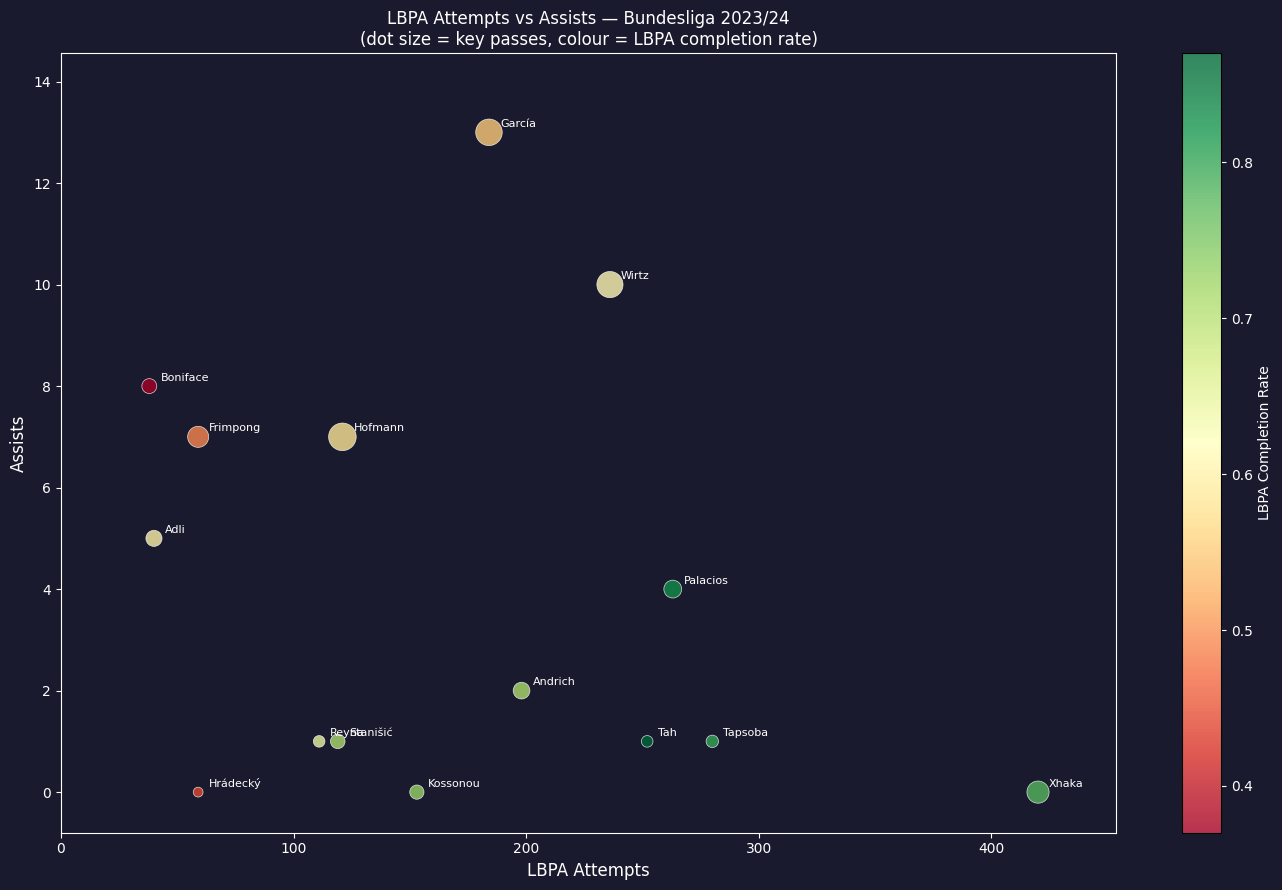

In [14]:

# CELL 12: Scatter plot — LBPA attempts vs assists

 
plot_df = player_df[player_df['lbpa_attempts'] >= 30].copy()
 
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
 
scatter = ax.scatter(
    plot_df['lbpa_attempts'],
    plot_df['assists'],
    s=plot_df['key_passes'] * 5 + 50,
    c=plot_df['lbpa_completion_rate'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)
 
for _, row in plot_df.iterrows():
    ax.annotate(
        row['player'].split()[-1],
        (row['lbpa_attempts'], row['assists']),
        textcoords="offset points",
        xytext=(8, 4),
        color='white',
        fontsize=8
    )
 
# Padding so no points are clipped
x_pad = plot_df['lbpa_attempts'].max() * 0.08
y_pad = plot_df['assists'].max() * 0.12
ax.set_xlim(0, plot_df['lbpa_attempts'].max() + x_pad)
ax.set_ylim(-0.8, plot_df['assists'].max() + y_pad)
 
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('LBPA Completion Rate', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
 
ax.set_xlabel('LBPA Attempts', color='white', fontsize=12)
ax.set_ylabel('Assists', color='white', fontsize=12)
ax.set_title('LBPA Attempts vs Assists — Bundesliga 2023/24\n(dot size = key passes, colour = LBPA completion rate)',
             color='white', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
 
plt.tight_layout()
plt.show()

In [15]:

# CELL 13: Build ML dataset — predict LBPA from pass features alone


# Target is already in all_results_df — no possession lookup needed
# Goal: can we predict whether a pass is an LBPA without freeze frame data?
# This would allow LBPA detection on any match, not just those with 360 data

lbpa_ml = all_results_df.copy()

print(f"Total passes: {len(lbpa_ml)}")
print(f"Target distribution:")
print(lbpa_ml['is_lbpa'].value_counts(normalize=True).round(3))
print(f"\nClass counts:")
print(lbpa_ml['is_lbpa'].value_counts())

Total passes: 165557
Target distribution:
is_lbpa
False    0.781
True     0.219
Name: proportion, dtype: float64

Class counts:
is_lbpa
False    129253
True      36304
Name: count, dtype: int64


In [16]:

# CELL 15b: Empirical comparison — ML model vs rule-based detector


# Rule-based labels (ground truth)
y_true = y_test

# ML model predictions at default threshold
y_pred_model = best_model.predict(X_test)

# Agreement rate
agreement = (y_true == y_pred_model).mean()
print(f"Agreement rate: {agreement:.3f} ({agreement*100:.1f}%)")

# Where they disagree
disagree = X_test.copy()
disagree['rule_based'] = y_true.values
disagree['ml_predicted'] = y_pred_model

# False positives — model says LBPA, rule-based says no
fp = disagree[(disagree['rule_based'] == 0) & (disagree['ml_predicted'] == 1)]
# False negatives — model says no, rule-based says LBPA
fn = disagree[(disagree['rule_based'] == 1) & (disagree['ml_predicted'] == 0)]

print(f"\nTotal disagreements: {len(fp) + len(fn)}")
print(f"  Model predicts LBPA, rule-based disagrees: {len(fp)}")
print(f"  Rule-based detects LBPA, model misses: {len(fn)}")

print(f"\nDisagreement breakdown by feature (false positives):")
print(fp[['end_y', 'pass_angle', 'progression', 'dist_to_goal_end']].describe().round(2))

print(f"\nDisagreement breakdown by feature (false negatives):")
print(fn[['end_y', 'pass_angle', 'progression', 'dist_to_goal_end']].describe().round(2))

NameError: name 'y_test' is not defined

In [ ]:

# CELL 14: Feature engineering — pass-level features only
# (no freeze frame data required)


def distance_to_goal(x, y, goal_x=120, goal_y=40):
    return np.sqrt((goal_x - x)**2 + (goal_y - y)**2)

def pass_length(x, y, end_x, end_y):
    return np.sqrt((end_x - x)**2 + (end_y - y)**2)

def pass_angle(x, y, end_x, end_y):
    return np.arctan2(end_y - y, end_x - x)

ml_df = lbpa_ml.copy()

ml_df['pass_length']        = pass_length(ml_df['x'], ml_df['y'], ml_df['end_x'], ml_df['end_y'])
ml_df['pass_angle']         = pass_angle(ml_df['x'], ml_df['y'], ml_df['end_x'], ml_df['end_y'])
ml_df['dist_to_goal_start'] = distance_to_goal(ml_df['x'], ml_df['y'])
ml_df['dist_to_goal_end']   = distance_to_goal(ml_df['end_x'], ml_df['end_y'])
ml_df['progression']        = ml_df['end_x'] - ml_df['x']
ml_df['period_enc']         = ml_df['period'].astype(int)

# Only pass-level features — no freeze frame, no outcome
features = [
    'x', 'y', 'end_x', 'end_y',
    'pass_length', 'pass_angle',
    'dist_to_goal_start', 'dist_to_goal_end',
    'progression', 'period_enc'
]

X = ml_df[features]
y = ml_df['is_lbpa'].astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Nulls: {X.isnull().sum().sum()}")
print(f"Class balance: {y.value_counts().to_dict()}")

In [ ]:

# CELL 15: Multi-model comparison + best model evaluation


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}\n")

# Compute sample weights to handle class imbalance
sample_weights = compute_sample_weight('balanced', y_train)

# Define models with class balancing
models = {
    'Logistic Regression' : Pipeline([('scaler', StandardScaler()),
                                      ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))]),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

# Cross-validated ROC-AUC
print("5-fold cross-validated ROC-AUC (train set):")
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f"  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Pick best model
best_name = max(cv_scores, key=cv_scores.get)
print(f"\nBest model: {best_name}")

# Fit best model — pass sample weights for Gradient Boosting
best_model = models[best_name]
if best_name == 'Gradient Boosting':
    best_model.fit(X_train, y_train, sample_weight=sample_weights)
else:
    best_model.fit(X_train, y_train)

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred       = best_model.predict(X_test)
roc_auc      = roc_auc_score(y_test, y_pred_proba)

print(f"Test ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
try:
    clf = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model
    importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
    print("Feature importances:")
    print(importances.round(4))
except:
    print("(Feature importances not available)")

# ROC curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax, color='#00b4d8')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set_title(f'ROC Curve — Pass → Shot within 5 Events ({best_name})', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:

# CELL 16: Feature importance bar chart

 
feature_labels = {
    'dist_to_goal_start'  : 'Distance to Goal (pass start)',
    'outcome_enc'         : 'Pass Completed',
    'dist_to_goal_end'    : 'Distance to Goal (pass end)',
    'pass_angle'          : 'Pass Angle',
    'end_y'               : 'Pass Destination (lateral)',
    'pass_length'         : 'Pass Length',
    'progression'         : 'Distance Gained',
    'x'                   : 'Pass Start X',
    'end_x'               : 'Pass End X',
    'progression_depth'   : 'Progression Depth',
    'y'                   : 'Pass Start Y',
    'period_enc'          : 'Match Period',
    'n_defenders_bypassed': 'Defenders Bypassed',
    'n_lines_broken'      : 'Lines Broken',
}
 
imp_plot = importances.rename(index=feature_labels).sort_values()
 
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
 
colours = ['#e63946' if 'Lines' in k or 'Defenders' in k else '#00b4d8'
           for k in imp_plot.index]
 
ax.barh(imp_plot.index, imp_plot.values, color=colours, edgecolor='none')
ax.set_xlabel('Feature Importance', color='white', fontsize=11)
ax.set_title('Feature Importances — Gradient Boosting Model\n(red = LBPA-specific features)',
             color='white', fontsize=11)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
 
plt.tight_layout()
plt.show()

In [ ]:

# CELL 17: Threshold tuning


from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find threshold that maximises F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Default threshold (0.5):")
default_preds = (y_pred_proba >= 0.5).astype(int)
print(classification_report(y_test, default_preds))

print(f"Optimal threshold ({best_threshold:.3f}):")
optimal_preds = (y_pred_proba >= best_threshold).astype(int)
print(classification_report(y_test, optimal_preds))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# Precision-Recall curve
axes[0].plot(recalls, precisions, color='#00b4d8', lw=2)
axes[0].axvline(recalls[best_idx], color='#e63946', linestyle='--',
                label=f'Optimal threshold ({best_threshold:.2f})')
axes[0].set_xlabel('Recall', color='white')
axes[0].set_ylabel('Precision', color='white')
axes[0].set_title('Precision-Recall Curve', color='white')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='#00b4d8', lw=2)
axes[1].axvline(best_threshold, color='#e63946', linestyle='--',
                label=f'Best F1 = {best_f1:.3f}')
axes[1].set_xlabel('Threshold', color='white')
axes[1].set_ylabel('F1 Score', color='white')
axes[1].set_title('F1 Score vs Decision Threshold', color='white')
axes[1].legend(facecolor='#1a1a2e', labelcolor='white')

plt.suptitle('Threshold Tuning — LBPA Detection Model', color='white', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:

# CELL 19: Save model


import pickle

with open("lbpa_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved to lbpa_model.pkl")

# To load it back later:
# with open("lbpa_model.pkl", "rb") as f:
#     loaded_model = pickle.load(f)